# Intro

The KNN model was used as the main model for the paper that inspired our work. We will implement this model as a baseline to compare against the graph based models. 

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os, shutil, subprocess

WORK_DIR = '/content/drive/MyDrive/DL_Project'
os.chdir(WORK_DIR)
print('cwd:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cwd: /content/drive/MyDrive/DL_Project


In [2]:
# install cuml
!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


## Read in 

In [3]:
import polars as pl

In [4]:
cabi = pl.read_parquet('data/cabi_demand_imputed_master.parquet')
cabi

start_station_id,started_at_15,deps,arrs,demand,station_name,latitude,longitude,STATEFP,COUNTYFP,TRACTCE_right,GEOIDFQ,GEOID_right,NAME.x,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,NAME.y,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,year,state,in_low_stress_bikeshed,in_total_bikeshed,latitude_right,longitude_right,index_right,GEOID10,GEOID20,D1B,D2B_E8MIX,D3B,D4A,D3AMM,D3BMM4,NatWalkInd
f64,"datetime[μs, UTC]",i32,i32,i32,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,i64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64
22907.0,2026-01-15 17:00:00 UTC,1,1,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1,38.918767,-76.965328,61407.0,"""110010111001""","""110010111001""",5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667
22907.0,2026-01-15 17:15:00 UTC,2,2,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1,38.918767,-76.965328,61407.0,"""110010111001""","""110010111001""",5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667
22907.0,2026-01-15 17:45:00 UTC,2,2,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1,38.918767,-76.965328,61407.0,"""110010111001""","""110010111001""",5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667
22907.0,2026-01-15 18:00:00 UTC,1,1,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1,38.918767,-76.965328,61407.0,"""110010111001""","""110010111001""",5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667
22907.0,2026-01-15 18:15:00 UTC,1,1,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1,38.918767,-76.965328,61407.0,"""110010111001""","""110010111001""",5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
33204.0,2026-03-31 20:30:00 UTC,0,1,1,"""15th & Chapin St NW""",38.921468,-77.035244,"""11""","""001""","""003701""","""1400000US11001003701""","""11001003701""","""37.01""","""Census Tract 37.01""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",172840.0,0.0,"""Census Tract 37.01; District o…",2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,2024.0,"""DC""",1,1,38.921468,-77.035244,61550.0,"""110010037003""","""110010037003""",102.323743,0.952048,1350.231831,414.41,12.036012,23.270631,14.666667
33204.0,2026-03-31 20:45:00 UTC,0,1,

# Prepare data

We only want to read in the metrics we need, so lets select down the metrics to just the ones we want, and then maybe add some temporal features.

## Feature Selection

In [5]:
cabi.columns

['start_station_id',
 'started_at_15',
 'deps',
 'arrs',
 'demand',
 'station_name',
 'latitude',
 'longitude',
 'STATEFP',
 'COUNTYFP',
 'TRACTCE_right',
 'GEOIDFQ',
 'GEOID_right',
 'NAME.x',
 'NAMELSAD',
 'STUSPS',
 'NAMELSADCO',
 'STATE_NAME',
 'LSAD',
 'ALAND',
 'AWATER',
 'NAME.y',
 'total_popE',
 'total_popM',
 'pop_maleE',
 'pop_maleM',
 'pop_femaleE',
 'pop_femaleM',
 'median_ageE',
 'median_ageM',
 'median_hh_incomeE',
 'median_hh_incomeM',
 'year',
 'state',
 'in_low_stress_bikeshed',
 'in_total_bikeshed',
 'latitude_right',
 'longitude_right',
 'index_right',
 'GEOID10',
 'GEOID20',
 'D1B',
 'D2B_E8MIX',
 'D3B',
 'D4A',
 'D3AMM',
 'D3BMM4',
 'NatWalkInd']

In [6]:
cabi_selected = cabi[["start_station_id","latitude", "longitude","started_at_15", "demand", "STATE_NAME", 'total_popE',
 'total_popM',
 'pop_maleE',
 'pop_maleM',
 'pop_femaleE',
 'pop_femaleM',
 'median_ageE',
 'median_ageM',
 'median_hh_incomeE',
 'median_hh_incomeM',
'in_low_stress_bikeshed',
 'in_total_bikeshed',
 'D1B',
 'D2B_E8MIX',
 'D3B',
 'D4A',
 'D3AMM',
 'D3BMM4',
 'NatWalkInd']]

## Feature Engineering
We also want to add calendar variables to the dataset, this way the model understands what time it is, the season, month, etc...

### Time Based Features

In [7]:
import numpy as np
# core time features
cabi_selected = cabi_selected.with_columns([
    pl.col("started_at_15").dt.hour().alias("hour"),
    pl.col("started_at_15").dt.minute().alias("minute"),
    pl.col("started_at_15").dt.weekday().alias("day_of_week"), 
    pl.col("started_at_15").dt.month().alias("month"),
    pl.col("started_at_15").dt.week().alias("week_of_year"),
    (pl.col("started_at_15").dt.weekday() >= 5).cast(pl.Int8).alias("is_weekend")
])
# add in sin / cos to capture the cycle of days

cabi_selected = cabi_selected.with_columns([ # conver to radians
    (2 * np.pi * pl.col("day_of_week") / 7).alias("_dow_rad"),
    (2 * np.pi * pl.col("week_of_year") / 52).alias("_woy_rad")
]).with_columns([
    pl.col("_dow_rad").sin().alias("day_of_week_sin"),
    pl.col("_dow_rad").cos().alias("day_of_week_cos"),
    pl.col("_woy_rad").sin().alias("week_of_year_sin"),
    pl.col("_woy_rad").cos().alias("week_of_year_cos")
]).drop(["_dow_rad", "_woy_rad"])

cabi_selected

start_station_id,latitude,longitude,started_at_15,demand,STATE_NAME,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,in_low_stress_bikeshed,in_total_bikeshed,D1B,D2B_E8MIX,D3B,D4A,D3AMM,D3BMM4,NatWalkInd,hour,minute,day_of_week,month,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,week_of_year_sin,week_of_year_cos
f64,f64,f64,"datetime[μs, UTC]",i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i8,i8,i8,i8,i8,i8,f64,f64,f64,f64
22907.0,38.918767,-76.965328,2026-01-15 17:00:00 UTC,0,"""District of Columbia""",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,0,1,5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667,17,0,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016
22907.0,38.918767,-76.965328,2026-01-15 17:15:00 UTC,0,"""District of Columbia""",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,0,1,5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667,17,15,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016
22907.0,38.918767,-76.965328,2026-01-15 17:45:00 UTC,0,"""District of Columbia""",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,0,1,5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667,17,45,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016
22907.0,38.918767,-76.965328,2026-01-15 18:00:00 UTC,0,"""District of Columbia""",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,0,1,5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667,18,0,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016
22907.0,38.918767,-76.965328,2026-01-15 18:15:00 UTC,0,"""District of Columbia""",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,0,1,5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667,18,15,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
33204.0,38.921468,-77.035244,2026-03-31 20:30:00 UTC,1,"""District of Columbia""",2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,1,1,102.323743,0.952048,1350.231831,414.41,12.036012,23.270631,14.666667,20,30,2,3,14,0,0.974928,-0.222521,0.992709,-0.120537
33204.0,38.921468,-77.035244,2026-03-31 20:45:00 UTC,1,"""District of Columbia""",2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,1,1,102.323743,0.952048,1350.231831,414.41,12.036012,23.270631,14.666667,20,45,2,3,14,0,0.974928,-0.222521,0.992709,-0.120537
33204.0,38.921468,-77.035244,2026-03-31 22:45:00 UTC,1,"""District of Columbia""",2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,1,1,102.323743,0.952048,1350.231831,414.41,12.036012,23.270631,14.666667,22,45,2,3,14,0,0.974928,-0.222521,0.992709,-0.120537


In [8]:
print(cabi_selected.select(pl.col("started_at_15").min()))
print(cabi_selected.select(pl.col("started_at_15").max()))

shape: (1, 1)
┌─────────────────────────┐
│ started_at_15           │
│ ---                     │
│ datetime[μs, UTC]       │
╞═════════════════════════╡
│ 2022-01-01 00:00:00 UTC │
└─────────────────────────┘
shape: (1, 1)
┌─────────────────────────┐
│ started_at_15           │
│ ---                     │
│ datetime[μs, UTC]       │
╞═════════════════════════╡
│ 2026-03-31 23:45:00 UTC │
└─────────────────────────┘


In [9]:
# Add in holiday nformation
from pandas.tseries.holiday import USFederalHolidayCalendar
hol_cal = USFederalHolidayCalendar()
holidays_pd = hol_cal.holidays(start="2022-01-01", end="2026-03-31") # based on min and max of our cabi data
# convert to polars
holidays_pl = pl.DataFrame({
    "date" : pl.Series(holidays_pd.normalize())
}).with_columns([pl.col("date").cast(pl.Date),
                pl.lit(1).cast(pl.Int8).alias("is_holiday")])
# join
cabi_selected = cabi_selected.with_columns(
    pl.col("started_at_15").dt.date().alias("date")
).join(holidays_pl, on="date", how="left").with_columns(
    pl.col("is_holiday").fill_null(0)
)

In [10]:
cabi_selected

start_station_id,latitude,longitude,started_at_15,demand,STATE_NAME,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,in_low_stress_bikeshed,in_total_bikeshed,D1B,D2B_E8MIX,D3B,D4A,D3AMM,D3BMM4,NatWalkInd,hour,minute,day_of_week,month,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,week_of_year_sin,week_of_year_cos,date,is_holiday
f64,f64,f64,"datetime[μs, UTC]",i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i8,i8,i8,i8,i8,i8,f64,f64,f64,f64,date,i8
22907.0,38.918767,-76.965328,2026-01-15 17:00:00 UTC,0,"""District of Columbia""",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,0,1,5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667,17,0,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016,2026-01-15,0
22907.0,38.918767,-76.965328,2026-01-15 17:15:00 UTC,0,"""District of Columbia""",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,0,1,5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667,17,15,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016,2026-01-15,0
22907.0,38.918767,-76.965328,2026-01-15 17:45:00 UTC,0,"""District of Columbia""",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,0,1,5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667,17,45,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016,2026-01-15,0
22907.0,38.918767,-76.965328,2026-01-15 18:00:00 UTC,0,"""District of Columbia""",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,0,1,5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667,18,0,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016,2026-01-15,0
22907.0,38.918767,-76.965328,2026-01-15 18:15:00 UTC,0,"""District of Columbia""",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,0,1,5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667,18,15,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016,2026-01-15,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
33204.0,38.921468,-77.035244,2026-03-31 20:30:00 UTC,1,"""District of Columbia""",2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,1,1,102.323743,0.952048,1350.231831,414.41,12.036012,23.270631,14.666667,20,30,2,3,14,0,0.974928,-0.222521,0.992709,-0.120537,2026-03-31,0
33204.0,38.921468,-77.035244,2026-03-31 20:45:00 UTC,1,"""District of Columbia""",2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,1,1,102.323743,0.952048,1350.231831,414.41,12.036012,23.270631,14.666667,20,45,2,3,14,0,0.974928,-0.222521,0.992709,-0.120537,2026-03-31,0
33204.0,38.921468,-77.035244,2026-03-31 22:45:00 UTC,1,"""District of Columbia""",2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,1,1,102.323743,0.952048,1350.231831,414.41,12.036012,23.270631,14.666667,22,45,2,3,14,0,0.974928,-0.222521,0.992709,-0.120537,2026-03-31,0


### Lag Features

In [11]:
cabi_selected = cabi_selected.sort("start_station_id", "started_at_15") # sort this ho
# add lagged demand
cabi_selected = cabi_selected.with_columns([
    # 15 min
    pl.col("demand").shift(1).over("start_station_id").alias("demand_lag_15min"),
    # 1 hour
    pl.col("demand").shift(4).over("start_station_id").alias("demand_lag_hour"),
    # 1 day
    pl.col("demand").shift(96).over("start_station_id").alias("demand_lag_day"),
    # 1 week
    pl.col("demand").shift(672).over("start_station_id").alias("demand_lag_week"),
])
# add rolling mean of demand

cabi_selected = cabi_selected.with_columns([
    # 1 hour
    pl.col("demand").shift(1).rolling_mean(window_size=4).over("start_station_id").alias("demand_rolling_mean_1hr"),
    # 1 day
    pl.col("demand").shift(1).rolling_mean(window_size=96).over("start_station_id").alias("demand_rolling_mean_1day")
])

### Assess Quality
Lets double check to make sure there arnt nulls / NAs

In [12]:
cabi_selected.null_count()

start_station_id,latitude,longitude,started_at_15,demand,STATE_NAME,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,in_low_stress_bikeshed,in_total_bikeshed,D1B,D2B_E8MIX,D3B,D4A,D3AMM,D3BMM4,NatWalkInd,hour,minute,day_of_week,month,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,week_of_year_sin,week_of_year_cos,date,is_holiday,demand_lag_15min,demand_lag_hour,demand_lag_day,demand_lag_week,demand_rolling_mean_1hr,demand_rolling_mean_1day
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,862,3445,82315,559651,3445,82315


# Modeling
Now lets try a KNN model

In [63]:
#cabi_ready = cabi_selected.drop(pl.col("started_at_15"))
cabi_ready = cabi_selected.drop(pl.col("date"))
cabi_ready = cabi_ready.drop(pl.col("start_station_id"))
# lets also onehot encode the state variable

cabi_ready = cabi_ready.to_dummies("STATE_NAME")

cabi_ready = cabi_ready.drop_nulls()

In [64]:
cabi_ready

latitude,longitude,started_at_15,demand,STATE_NAME_District of Columbia,STATE_NAME_Maryland,STATE_NAME_Virginia,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,in_low_stress_bikeshed,in_total_bikeshed,D1B,D2B_E8MIX,D3B,D4A,D3AMM,D3BMM4,NatWalkInd,hour,minute,day_of_week,month,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,week_of_year_sin,week_of_year_cos,is_holiday,demand_lag_15min,demand_lag_hour,demand_lag_day,demand_lag_week,demand_rolling_mean_1hr,demand_rolling_mean_1day
f64,f64,"datetime[μs, UTC]",i32,u8,u8,u8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i8,i8,i8,i8,i8,i8,f64,f64,f64,f64,i8,i32,i32,i32,i32,f64,f64
38.894183,-77.023874,2023-03-07 18:15:00 UTC,-1,1,0,0,1843.0,327.0,1084.0,257.0,759.0,175.0,41.8,5.7,198295.0,56120.0,1,1,10.792557,0.687402,214.108979,56.33,9.352917,49.40041,18.166667,18,15,2,3,10,0,0.974928,-0.222521,0.935016,0.354605,0,-3,-1,-1,1,-1.0,0.666667
38.894183,-77.023874,2023-03-07 21:15:00 UTC,-3,1,0,0,1843.0,327.0,1084.0,257.0,759.0,175.0,41.8,5.7,198295.0,56120.0,1,1,10.792557,0.687402,214.108979,56.33,9.352917,49.40041,18.166667,21,15,2,3,10,0,0.974928,-0.222521,0.935016,0.354605,0,-1,2,-1,1,-1.0,0.666667
38.894183,-77.023874,2023-03-07 21:45:00 UTC,-1,1,0,0,1843.0,327.0,1084.0,257.0,759.0,175.0,41.8,5.7,198295.0,56120.0,1,1,10.792557,0.687402,214.108979,56.33,9.352917,49.40041,18.166667,21,45,2,3,10,0,0.974928,-0.222521,0.935016,0.354605,0,-3,-2,2,1,-2.25,0.645833
38.894183,-77.023874,2023-03-07 22:00:00 UTC,-1,1,0,0,1843.0,327.0,1084.0,257.0,759.0,175.0,41.8,5.7,198295.0,56120.0,1,1,10.792557,0.687402,214.108979,56.33,9.352917,49.40041,18.166667,22,0,2,3,10,0,0.974928,-0.222521,0.935016,0.354605,0,-1,-3,4,2,-2.0,0.614583
38.894183,-77.023874,2023-03-08 08:15:00 UTC,1,1,0,0,1843.0,327.0,1084.0,257.0,759.0,175.0,41.8,5.7,198295.0,56120.0,1,1,10.792557,0.687402,214.108979,56.33,9.352917,49.40041,18.166667,8,15,3,3,10,0,0.433884,-0.900969,0.935016,0.354605,0,-1,-1,2,1,-1.5,0.5625
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
38.921468,-77.035244,2026-03-31 21:30:00 UTC,-1,1,0,0,2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,1,1,102.323743,0.952048,1350.231831,414.41,12.036012,23.270631,14.666667,21,30,2,3,14,0,0.974928,-0.222521,0.992709,-0.120537,0,1,-1,-1,-1,0.75,0.052083
38.921468,-77.035244,2026-03-31 22:15:00 UTC,0,1,0,0,2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,1,1,102.323743,0.952048,1350.231831,414.41,12.036012,23.270631,14.666667,22,15,2,3,14,0,0.974928,-0.222521,0.992709,-0.120537,0,-1,2,2,-1,0.75,0.052083
38.921468,-77.035244,2026-03-31 22:45:00 UTC,1,1,0,0,2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,1,1,102.323743,0.952048,1350.231831,414.41,12.036012,23.270631,14.666667,22,45,2,3,14,0,0.974928,-0.222521,0.992709,-0.120537,0,0,1,-2,-1,0.25,0.03125


In [65]:
from sklearn.model_selection import train_test_split
#from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from cuml.neighbors import KNeighborsRegressor
import cudf

In [ ]:
cabi_ready = cabi_ready.sample(fraction = 0.1)
# lets split into X and y
X = cabi_ready.drop(pl.col("demand")).to_pandas()
y = cabi_ready.select(pl.col("demand")).to_pandas()
# first lets split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# transfer to gpu
X_train_gpu = cudf.DataFrame(X_train.astype('float32'))
X_test_gpu  = cudf.DataFrame(X_test.astype('float32'))
y_train_gpu = cudf.Series(y_train.values.ravel()) #gotta convert to a series

In [59]:
# initialize KNN and predict
neigh = KNeighborsRegressor(n_neighbors=5, weights = "distance")
neigh.fit(X_train_gpu, y_train_gpu)

KNeighborsRegressor()

In [60]:
sample_predicts = neigh.predict(X_test_gpu)


In [61]:
print("MAE:")
print(mean_absolute_error(y_test, sample_predicts.to_numpy()))
print("RMSE:")
print(root_mean_squared_error(y_test, sample_predicts.to_numpy()))
print("R2:")
print(r2_score(y_test, sample_predicts.to_numpy()))

MAE:
1.3052406311035156
RMSE:
1.6740071773529053
R2:
-0.1267848014831543


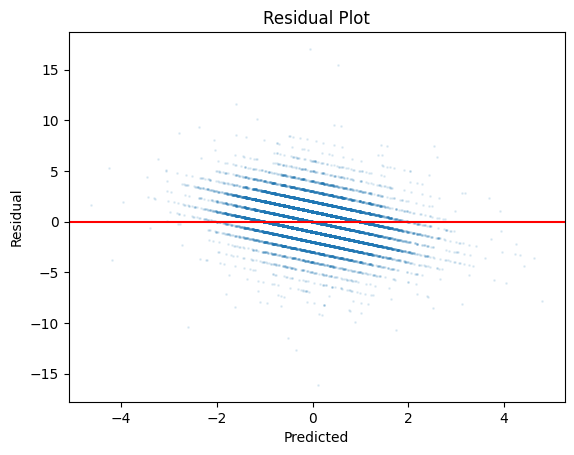

In [62]:
import matplotlib.pyplot as plt
sample_predicts = sample_predicts.to_numpy()
residuals = y_test.values.ravel() - sample_predicts
plt.scatter(sample_predicts, residuals, alpha=0.1, s=1)
plt.axhline(0, color='red')
plt.xlabel("Predicted"); plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()
